<a href="https://colab.research.google.com/gist/KhawajaMuddassar/c28ac6e871ec05bae05c7c663936b729/untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Train Diffusion Model from Scratch**

We will train a UNet2DModel from scratch on a subset of the Butterflies dataset to generate new more beautyfull 🦋 butterflies 🦋 as Unconditional image generation

In [ ]:
# Install Dependencies
%%capture
!pip install diffusers[training]=0.11.1
!pip install datasets

In [ ]:
# Authentication token from the Hugging Face
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
%%capture
!sudo apt -qq install git-lfs
!git config --global credential.helper store

# **Training Configuration**
For convenience, define a configuration grouping all the training hyperparameters. Here we choose reasonable defaults for hyperparameters like num_epochs, learning_rate, lr_warmup_steps, but feel free to adjust them if you train on your own dataset. For example, num_epochs can be increased to 100 for better visual quality

In [ ]:
from dataclasses import dataclass

@dataclass
class TrainingConfig:
    image_size = 128  # the generated image resolution
    train_batch_size = 16
    eval_batch_size = 16  # how many images to sample during evaluation
    num_epochs = 50
    gradient_accumulation_steps = 1
    learning_rate = 1e-4
    lr_warmup_steps = 500
    save_image_epochs = 10
    save_model_epochs = 30
    mixed_precision = 'fp16'  # `no` for float32, `fp16` for automatic mixed precision
    output_dir = 'ddpm-butterflies-128'  # the model namy locally and on the HF Hub
    logging_dir = './logs'
    push_to_hub = True  # whether to upload the saved model to the HF Hub
    hub_private_repo = False
    overwrite_output_dir = True  # overwrite the old model when re-running the notebook
    seed = 0

config = TrainingConfig()


# **Inspect Dataset**

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Repo card metadata block was not found. Setting CardData to empty.


image_url, : Value(dtype='string', id=None)
image_alt, : Value(dtype='string', id=None)
id, : Value(dtype='string', id=None)
name, : Value(dtype='string', id=None)
scientific_name, : Value(dtype='string', id=None)
gender, : Value(dtype='string', id=None)
taxonomy, : Value(dtype='string', id=None)
region, : Value(dtype='string', id=None)
locality, : Value(dtype='string', id=None)
date, : Value(dtype='string', id=None)
usnm_no, : Value(dtype='string', id=None)
guid, : Value(dtype='string', id=None)
edan_url, : Value(dtype='string', id=None)
source, : Value(dtype='string', id=None)
stage, : Value(dtype='float64', id=None)
image, : Image(mode=None, decode=True, id=None)
image_hash, : Value(dtype='string', id=None)
sim_score, : Value(dtype='float64', id=None)


Repo card metadata block was not found. Setting CardData to empty.


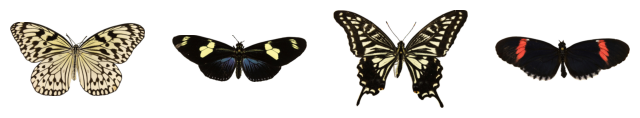

In [ ]:
# Data Attributes
from datasets import load_dataset_builder
from datasets import load_dataset
import matplotlib.pyplot as plt

config.dataset_name = "huggan/smithsonian_butterflies_subset"

# Dataset Attributes
ds_builder = load_dataset_builder(config.dataset_name)
features = ds_builder.info.features
for feature_name, feature in features.items():
    print(f"{feature_name}, : {feature}")

# Load Dataset
dataset = load_dataset(config.dataset_name, split="train")

# Display Sample Image
fig, axs = plt.subplots(1, 4, figsize=(8, 4))
for i, image in enumerate(dataset[:4]["image"]):
    axs[i].imshow(image)
    axs[i].set_axis_off()
fig.show()

# **Preprocess Images**

Images in dataset are different so we need to preprocess them first.
* **Resize** makes the images conform to a square resolution
* **RandomHorizontalFlip** augments the dataset by randomly mirroring the images.
* **Normalize** is important to rescale the pixel values into a [-1, 1] range (which our model will expect).

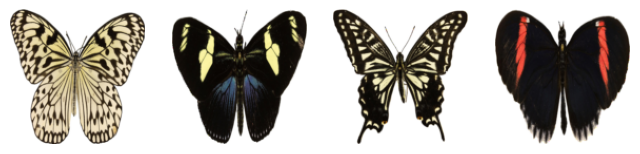

In [ ]:
import torch
from torchvision import transforms

preprocess = transforms.Compose([
        transforms.Resize((config.image_size, config.image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),])

# Apply transformation on fly during training
def transform(x):
    images = [preprocess(image.convert("RGB")) for image in x['image']]
    return {'images':images}

dataset.set_transform(transform)

# Recheck sample Images after transformation
fig, axs = plt.subplots(1, 4, figsize=(8, 4))
for i, image in enumerate(dataset[:4]["images"]):
    axs[i].imshow(image.permute(1, 2, 0).numpy() / 2 + 0.5)
    axs[i].set_axis_off()
fig.show()

# Define Dataloader
train_dataloader = torch.utils.data.DataLoader(dataset, batch_size=config.train_batch_size, shuffle=True)

## Defining the diffusion model

Diffusion models are neural networks that are trained to predict slightly less noisy images from a noisy input. At inference, they can be used to iteratively transform a random noise to generate an image. it's really easy to add some noise to an image, so the training can happen in a semi-supervised fashion as follows:
1. Take an image from the training set.
2. Apply to it some random noise $t$ times (this will give the $x_{t-1}$ and the $x_{t}$ in the figure above).
3. Give this noisy image to the model along with the value of $t$.
4. Compute a loss from the output of the model and the noised image $x_{t-1}$.

Then we can apply gradient descent and repeat this process multiple times.

Most diffusion models use architectures that are some variant of a U-net and that's what we'll use here.

![](https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/unet-model.png)

In a nutshell:

* the model has the input image go through several blocks of ResNet layers which halves the image size by 2
* then through the same number of blocks that upsample it again.
* there are skip connections linking the features on the downample path to the corresponsding layers in the upsample path.

A key feature of this model is that it predicts images of the same size as the input. Diffusers provides us a handy **UNet2DModel** class which creates the desired architecture in PyTorch.


In [ ]:
from diffusers import UNet2DModel

model = UNet2DModel(
    sample_size = config.image_size,
    in_channels = 3,
    out_channels= 3,
    layers_per_block= 2,
    block_out_channels=(128,128,256,256,512,512),
    down_block_types=(
        'DownBlock2D',  # Regular Resnet downsampling block
        'DownBlock2D',
        'DownBlock2D',
        'DownBlock2D',
        'AttnDownBlock2D',  # With Spatial Self-Attention
        'DownBlock2D',
    ),
    up_block_types=(
        'UpBlock2D', # Regular Resnet downsampling block
        'AttnUpBlock2D',    # With Spatial Self-Attention
        'UpBlock2D',
        'UpBlock2D',
        'UpBlock2D',
        'UpBlock2D',
    ))

# Pass sample from model and check input & output shapes
# Model takes in the (noisy) image and also the current time-step.
# time-step information is converted for the model using a sinusoidal positional embedding
sample_image = dataset[0]['images'].unsqueeze(0)
print('Input shape:', sample_image.shape)
print('Output shape:', model(sample_image, timestep=0).sample.shape)

Input shape: torch.Size([1, 3, 128, 128])
Output shape: torch.Size([1, 3, 128, 128])


# **Noise Scheduler**
Diffusers contains different scheduler classes which each define the algorithm-specific diffusion steps, therefore the way images are noised is slightly different. it takes a batch of images from the trainng set ( we will reuse the batch of one image sample_image form before), a batch of random noise of the same shape and the timesteps for each image (which correspond to the number of times we want to apply noise to each image)

In [ ]:
import torch
from PIL import Image
from diffusers import DDPMScheduler
import torch.nn.functional as F

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
noise = torch.randn(sample_image.shape)
timesteps = torch.LongTensor([50])
noisy_image = noise_scheduler.add_noise(sample_image, noise, timesteps)

Image.fromarray(((noisy_image.permute(0, 2, 3, 1) + 1.0) * 127.5).type(torch.uint8).numpy()[0])

# In the DDPM algorithm, the training objective of the model is then to be able to
# predict the noise we used in noise_scheduler.add_noise, so the loss at this step would be
noise_pred = model(noisy_image, timesteps).sample
loss = F.mse_loss(noise_pred, noise)

# **Pipeline**

In [ ]:
from diffusers.optimization import get_cosine_schedule_with_warmup
from diffusers import DDPMPipeline
import math , os

optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=config.lr_warmup_steps,
    num_training_steps=(len(train_dataloader) * config.num_epochs),)

def make_grid(images, rows, cols):
    w,h = images[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    for i, image in enumerate(images):
        grid.paste(image, box=(i%cols*w, i//cols*h))
    return grid

def evaluate(config, epoch, pipeline):
    images = pipeline(
        batch_size = config.eval_batch_size,
        generator = torch.manual_seed(config.seed)
    ).images
    #Make Image grid
    image_grid = make_grid(images, rows=4, cols=4)
    #save Images
    test_dir = os.path.join(config.output_dir,'Image_Samples')
    os.makedirs(test_dir, exist_ok=True)
    image_grid.save(f'{test_dir}/{epoch:04d}.png')



# **Model Training**

In [ ]:
from tqdm.auto import tqdm
import torch
import os
import torch.nn.functional as F
from pathlib import Path

def train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler):
    # Set up output directory
    if config.output_dir is not None:
        os.makedirs(config.output_dir, exist_ok=True)

    global_step = 0

    # Training loop
    for epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), desc=f"Epoch {epoch}")

        for step, batch in enumerate(train_dataloader):
            clean_images = batch['images']
            # Sample noise to add to the images
            noise = torch.randn(clean_images.shape).to(clean_images.device)
            bs = clean_images.shape[0]

            # Sample a random timestep for each image
            timesteps = torch.randint(0, noise_scheduler.num_train_timesteps, (bs,), device=clean_images.device).long()

            # Add noise to the clean images according to the noise magnitude at each timestep
            # (this is the forward diffusion process)
            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            # Predict the noise residual
            noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
            loss = F.mse_loss(noise_pred, noise)

            # Backpropagate the loss and update the model
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            lr_scheduler.step()

            # Logging progress
            progress_bar.update(1)
            progress_bar.set_postfix(loss=loss.detach().item(), lr=lr_scheduler.get_last_lr()[0], step=global_step)
            global_step += 1

        # After each epoch, optionally sample demo images and save the model
        if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
            pipeline = DDPMPipeline(unet=model, scheduler=noise_scheduler)
            evaluate(config, epoch, pipeline)

        if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
            # Save the model locally
            pipeline.save_pretrained(config.output_dir)


In [ ]:
from tqdm.auto import tqdm
import torch
import os
import torch.nn.functional as F
from pathlib import Path

def train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler):
    # Set up output directory
    if config.output_dir is not None:
        os.makedirs(config.output_dir, exist_ok=True)

    global_step = 0

    # Ensure the model is on the GPU
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    #noise_scheduler.to(device)

    # Training loop
    for epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), desc=f"Epoch {epoch}")

        for step, batch in enumerate(train_dataloader):
            clean_images = batch['images'].to(device)  # Ensure images are on the GPU

            # Sample noise to add to the images
            noise = torch.randn(clean_images.shape, device=device)  # Generate noise on GPU
            bs = clean_images.shape[0]

            # Sample a random timestep for each image
            timesteps = torch.randint(0, noise_scheduler.num_train_timesteps, (bs,), device=device).long()

            # Add noise to the clean images according to the noise magnitude at each timestep
            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            # Predict the noise residual
            noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
            loss = F.mse_loss(noise_pred, noise)

            # Backpropagate the loss and update the model
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            lr_scheduler.step()

            # Logging progress
            progress_bar.update(1)
            progress_bar.set_postfix(loss=loss.detach().item(), lr=lr_scheduler.get_last_lr()[0], step=global_step)
            global_step += 1

        # After each epoch, optionally sample demo images and save the model
        if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
            pipeline = DDPMPipeline(unet=model, scheduler=noise_scheduler)
            evaluate(config, epoch, pipeline)

        if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
            # Save the model locally
            pipeline.save_pretrained(config.output_dir)


In [ ]:
from accelerate import notebook_launcher
args = (config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler)

notebook_launcher(train_loop, args, num_processes=1)

Launching training on one GPU.


Epoch 0:   0%|          | 0/63 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/diffusers/configuration_utils.py:140: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch 1:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch 46:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 47:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 48:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 49:   0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

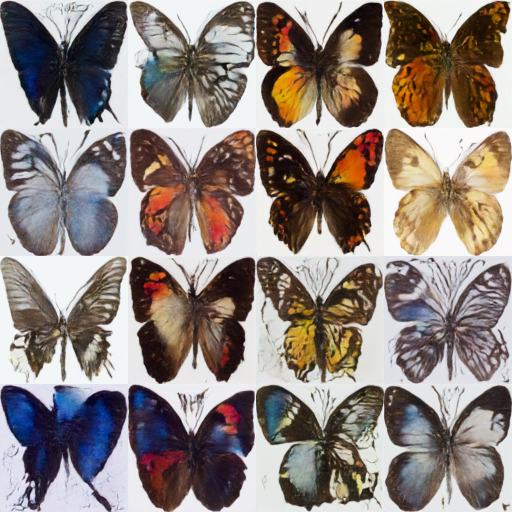

In [ ]:
import glob
#from glob import glob

sample_images = sorted(glob.glob(f"{config.output_dir}/Image_Samples/*.png"))
Image.open(sample_images[-1])